# VenturePulse: Startup Success Prediction

**MLOps Group Project - IE University**  
**Group 4:** Bojana Belincevic, David Carrillo, Sebastião Clemente, Bassem El Halawani, Theo Henry, Ocke Moulijn

---

## Project Overview

**Objective:** Predict which startups will achieve high traction within 18 months

**Business Context:**
- VCs receive 1,000+ pitches/year but invest in <1%
- 75% of VC-backed startups fail to return capital
- Current evaluation: mostly qualitative, network-dependent

**ML Solution:**
- Binary classification: `high_traction` (0/1)
- Primary metric: **Precision@100** (top 100 weekly recommendations)
- Features: Available at pitch stage only (no data leakage)

**Success Definition (at t=18 months):**
- Team growth ≥25% AND
- Revenue ≥$500K AND  
- MRR ≥$25K

---

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Imports loaded successfully")

✅ Imports loaded successfully


## Data Source

**Dataset:** `data/raw/venturepulse_dataset.csv`

**Specifications:**
- 30,000 synthetic startup records
- Generated with realistic VC correlations
- ~15-18% success rate (class imbalance)
- 12 features (6 base + 6 engineered)

**Data Split Strategy:**
- Train: 70% (3,500 samples)
- Validation: 15% (750 samples)  
- Test: 15% (750 samples)
- Stratified by target to maintain class balance

## Define Data Loading Function

In [2]:
def load_data(filepath='../data/raw/venturepulse_dataset.csv'):
    """
    Load the VenturePulse dataset.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
        
    Returns:
    --------
    pd.DataFrame
        Loaded dataset
    """
    print(f"Loading data from: {filepath}")
    df = pd.read_csv(filepath)
    
    print(f"✅ Data loaded successfully")
    print(f"   Shape: {df.shape}")
    print(f"   Success rate: {df['high_traction'].mean():.1%}")
    print(f"   Missing values: {df.isna().sum().sum()} ({df.isna().sum().sum()/(df.shape[0]*df.shape[1])*100:.2f}%)")
    
    return df


def split_data(df, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split data into train/validation/test sets with stratification.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
    test_size : float
        Proportion for test set
    val_size : float
        Proportion for validation set
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    tuple
        (df_train, df_val, df_test)
    """
    # First split: separate test set
    df_full_train, df_test = train_test_split(
        df,
        test_size=test_size,
        stratify=df['high_traction'],
        random_state=random_state
    )
    
    # Second split: separate validation from train
    val_size_adjusted = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_full_train,
        test_size=val_size_adjusted,
        stratify=df_full_train['high_traction'],
        random_state=random_state
    )
    
    print("\n📊 Data Split Summary:")
    print(f"   Train: {len(df_train):,} samples ({len(df_train)/len(df)*100:.1f}%)")
    print(f"   Val:   {len(df_val):,} samples ({len(df_val)/len(df)*100:.1f}%)")
    print(f"   Test:  {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%)")
    
    print("\n🎯 Success Rate by Split:")
    print(f"   Train: {df_train['high_traction'].mean():.1%}")
    print(f"   Val:   {df_val['high_traction'].mean():.1%}")
    print(f"   Test:  {df_test['high_traction'].mean():.1%}")
    
    return df_train, df_val, df_test

## Load and Split Data

In [3]:
# Load full dataset
df = load_data()

# Display first few rows
print("\n📋 First 5 rows:")
df.head()

Loading data from: ../data/raw/venturepulse_dataset.csv
✅ Data loaded successfully
   Shape: (30000, 23)
   Success rate: 25.0%
   Missing values: 2672 (0.39%)

📋 First 5 rows:


,funding_stage,sector,location,initial_funding_amount,team_size,months_since_founded,capital_efficiency,tier1_location,hot_sector,founder_background,team_diversity,market_timing,pmf_score,cac_efficiency,burn_rate,network_strength,founder_commitment,technical_moat,revenue_growth,has_customers,prev_experience,investor_quality,high_traction
0,Seed,Healthcare,Remote,645209.03,6,14,0.804,0,1,Average,High,0.608,0.879,8.49,0.055,0.291,0.592,0.352,10.50,1,0,0.706,0
1,Seed,Consumer,Silicon Valley,1204203.40,6,14,0.266,1,0,Average,High,0.349,0.679,4.96,0.045,0.748,0.517,0.655,5.18,1,0,0.660,0
2,Seed,EdTech,Tel Aviv,613068.22,10,19,0.182,0,0,Unknown,High,0.714,0.450,3.53,0.095,0.270,0.901,0.237,19.74,1,0,0.403,0
3,Pre-seed,AI/ML,NYC,187838.10,3,3,NaN,1,1,Unknown,Medium,0.855,0.821,5.25,0.044,0.857,0.880,0.781,7.71,0,0,0.414,0
4,Series A,Fintech,Austin,3372788.99,18,46,0.450,0,1,Strong,Medium,0.972,0.766,6.70,0.135,0.602,0.593,0.646,18.48,1,2,0.727,0


In [4]:
# Dataset info
print("\n📊 Dataset Info:")
df.info()


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   funding_stage           30000 non-null  object 
 1   sector                  30000 non-null  object 
 2   location                30000 non-null  object 
 3   initial_funding_amount  30000 non-null  float64
 4   team_size               30000 non-null  int64  
 5   months_since_founded    30000 non-null  int64  
 6   capital_efficiency      29089 non-null  float64
 7   tier1_location          30000 non-null  int64  
 8   hot_sector              30000 non-null  int64  
 9   founder_background      30000 non-null  object 
 10  team_diversity          30000 non-null  object 
 11  market_timing           29083 non-null  float64
 12  pmf_score               29156 non-null  float64
 13  cac_efficiency          30000 non-null  float64
 14  burn_rate            

In [5]:
# Split into train/val/test
df_train, df_val, df_test = split_data(df, test_size=0.15, val_size=0.15, random_state=42)


📊 Data Split Summary:
   Train: 21,000 samples (70.0%)
   Val:   4,500 samples (15.0%)
   Test:  4,500 samples (15.0%)

🎯 Success Rate by Split:
   Train: 25.0%
   Val:   25.0%
   Test:  25.0%


## Exploratory Data Analysis

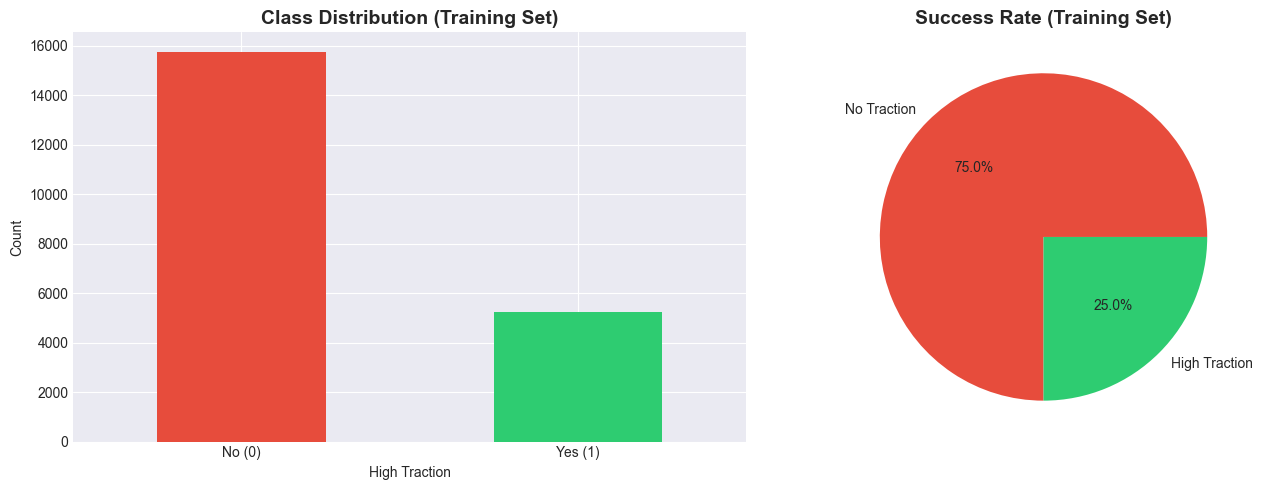


⚠️ Class Imbalance Ratio: 3.00:1


In [6]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df_train['high_traction'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71']
)
axes[0].set_title('Class Distribution (Training Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('High Traction')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

# Pie chart
df_train['high_traction'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    labels=['No Traction', 'High Traction']
)
axes[1].set_title('Success Rate (Training Set)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Class Imbalance Ratio: {(df_train['high_traction']==0).sum() / (df_train['high_traction']==1).sum():.2f}:1")

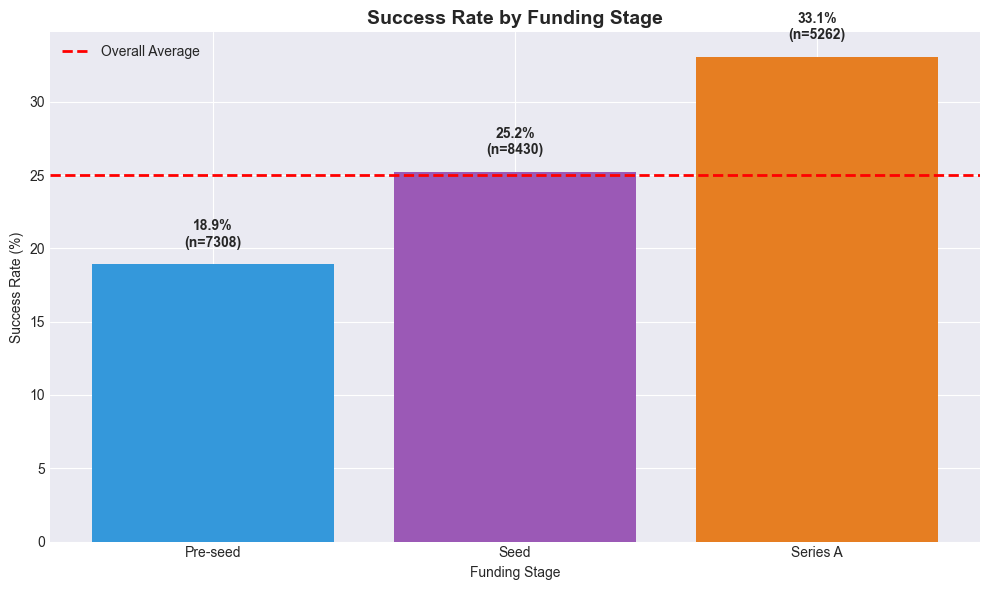


📈 Key Insight: Success rate increases with funding stage
   Pre-seed → Seed → Series A shows clear progression


In [7]:
# Success rate by funding stage
fig, ax = plt.subplots(figsize=(10, 6))

stage_success = df_train.groupby('funding_stage')['high_traction'].agg(['mean', 'count'])
stage_success['mean'] *= 100
stage_order = ['Pre-seed', 'Seed', 'Series A']
stage_success = stage_success.reindex(stage_order)

bars = ax.bar(range(len(stage_success)), stage_success['mean'], 
              color=['#3498db', '#9b59b6', '#e67e22'])
ax.set_xticks(range(len(stage_success)))
ax.set_xticklabels(stage_order)
ax.set_title('Success Rate by Funding Stage', fontsize=14, fontweight='bold')
ax.set_xlabel('Funding Stage')
ax.set_ylabel('Success Rate (%)')
ax.axhline(df_train['high_traction'].mean() * 100, 
           color='red', linestyle='--', label='Overall Average', linewidth=2)

# Add value labels
for i, (idx, row) in enumerate(stage_success.iterrows()):
    ax.text(i, row['mean'] + 1, 
            f"{row['mean']:.1f}%\n(n={int(row['count'])})",
            ha='center', va='bottom', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

print("\n📈 Key Insight: Success rate increases with funding stage")
print("   Pre-seed → Seed → Series A shows clear progression")

## Prepare Features

**Feature Engineering Strategy:**
1. **Categorical Features:** One-hot encoding for `sector`, `location`, `funding_stage`
2. **Numerical Features:** Keep as-is (already scaled appropriately)
3. **Binary Features:** `tier1_location`, `hot_sector`, `stage_funding_match` (already 0/1)
4. **Handle Missing Values:** Simple imputation with median for numerical features

**Important:** We use training data statistics to transform validation/test sets (prevent data leakage)

In [8]:
def prepare_features(df_train, df_val, df_test):
    """Prepare features for modeling - v2 with new features"""
    
    # Define all categorical columns
    categorical_cols = ['sector', 'location', 'funding_stage', 
                        'founder_background', 'team_diversity']
    
    # Separate features and target
    feature_cols = [col for col in df_train.columns if col != 'high_traction']
    
    X_train = df_train[feature_cols].copy()
    X_val = df_val[feature_cols].copy()
    X_test = df_test[feature_cols].copy()
    
    y_train = df_train['high_traction'].copy()
    y_val = df_val['high_traction'].copy()
    y_test = df_test['high_traction'].copy()
    
    # Handle missing values in numeric columns
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns
    impute_values = X_train[numeric_cols].median()
    
    for col in numeric_cols:
        X_train[col].fillna(impute_values[col], inplace=True)
        X_val[col].fillna(impute_values[col], inplace=True)
        X_test[col].fillna(impute_values[col], inplace=True)
    
    # One-hot encode categorical variables
    X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
    X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=False)
    X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)
    
    # Align columns
    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    print("\n🔧 Feature Engineering Complete:")
    print(f"Features: {X_train.shape[1]}")
    print(f"Numeric features: {len(numeric_cols)}")
    print(f"Categorical encoded: {len(categorical_cols)}")
    print(f"Train samples: {X_train.shape[0]:,}")
    print(f"Val samples: {X_val.shape[0]:,}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [9]:
# Prepare features
X_train, X_val, X_test, y_train, y_val, y_test = prepare_features(df_train, df_val, df_test)

# Display feature names (AHORA SÍ existe X_train)
print("\n📊 Feature List:")
for i, col in enumerate(X_train.columns, 1):
    print(f"   {i:2d}. {col}")


🔧 Feature Engineering Complete:
Features: 46
Numeric features: 17
Categorical encoded: 5
Train samples: 21,000
Val samples: 4,500

📊 Feature List:
    1. initial_funding_amount
    2. team_size
    3. months_since_founded
    4. capital_efficiency
    5. tier1_location
    6. hot_sector
    7. market_timing
    8. pmf_score
    9. cac_efficiency
   10. burn_rate
   11. network_strength
   12. founder_commitment
   13. technical_moat
   14. revenue_growth
   15. has_customers
   16. prev_experience
   17. investor_quality
   18. sector_AI/ML
   19. sector_Biotech
   20. sector_Climate
   21. sector_Consumer
   22. sector_EdTech
   23. sector_Fintech
   24. sector_Hardware
   25. sector_Healthcare
   26. sector_SaaS
   27. location_Austin
   28. location_Berlin
   29. location_Boston
   30. location_London
   31. location_NYC
   32. location_Remote
   33. location_Silicon Valley
   34. location_Singapore
   35. location_Tel Aviv
   36. location_Toronto
   37. funding_stage_Pre-seed
   3

## Train Baseline Model: Logistic Regression

**Why Logistic Regression First?**
- Simple, interpretable baseline
- Fast to train
- Establishes minimum performance threshold
- Coefficients show feature importance

**Key Parameter:** `class_weight='balanced'` to handle class imbalance

In [10]:
# Train Logistic Regression with balanced class weights
print("\n🚀 Training Logistic Regression...")
start_time = time.time()

model_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model_lr.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"✅ Training complete in {train_time:.2f} seconds")


🚀 Training Logistic Regression...
✅ Training complete in 0.59 seconds


### Model Coefficients (Feature Importance)


📊 Top 10 Most Important Features:
                   feature  coefficient
           prev_experience     0.226280
  founder_background_Elite     0.117013
founder_background_Unknown    -0.111248
    funding_stage_Pre-seed    -0.107793
                hot_sector     0.102546
founder_background_Average    -0.102228
             has_customers     0.084906
               sector_SaaS    -0.066087
            cac_efficiency    -0.060807
        founder_commitment    -0.050908


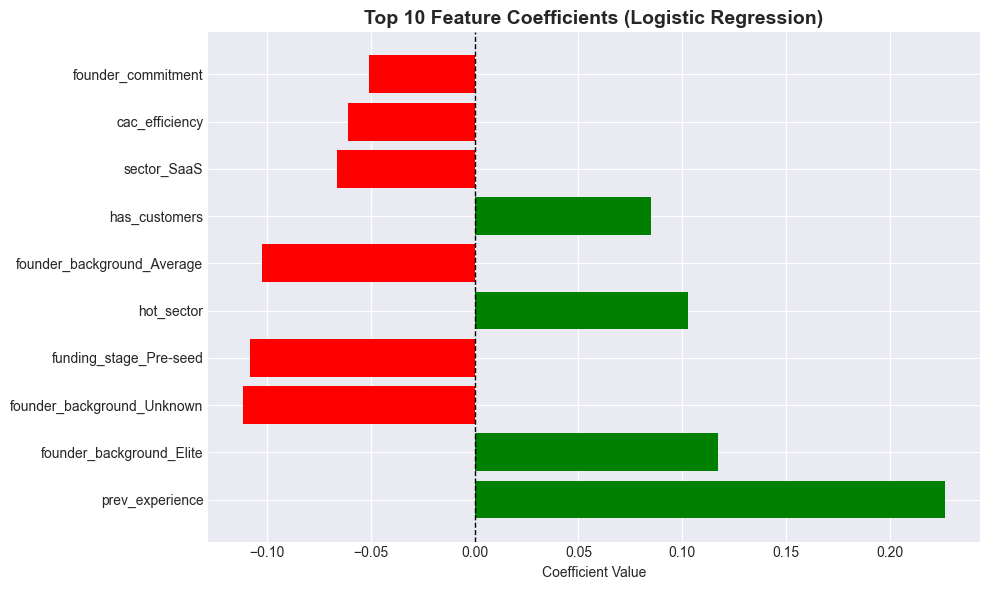

In [11]:
# Extract and display top coefficients
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(coefficients.head(10).to_string(index=False))

# Visualize top coefficients
fig, ax = plt.subplots(figsize=(10, 6))
top_features = coefficients.head(10)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
ax.barh(range(len(top_features)), top_features['coefficient'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 10 Feature Coefficients (Logistic Regression)', 
             fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Evaluate on Validation Set

In [12]:
# Make predictions
y_pred_val = model_lr.predict(X_val)
y_pred_proba_val = model_lr.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)
auc = roc_auc_score(y_val, y_pred_proba_val)

print("\n" + "="*70)
print("VALIDATION SET PERFORMANCE")
print("="*70)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("="*70)


VALIDATION SET PERFORMANCE
Accuracy:  0.5842
Precision: 0.3241
Recall:    0.6107
F1-Score:  0.4234
AUC-ROC:   0.6248


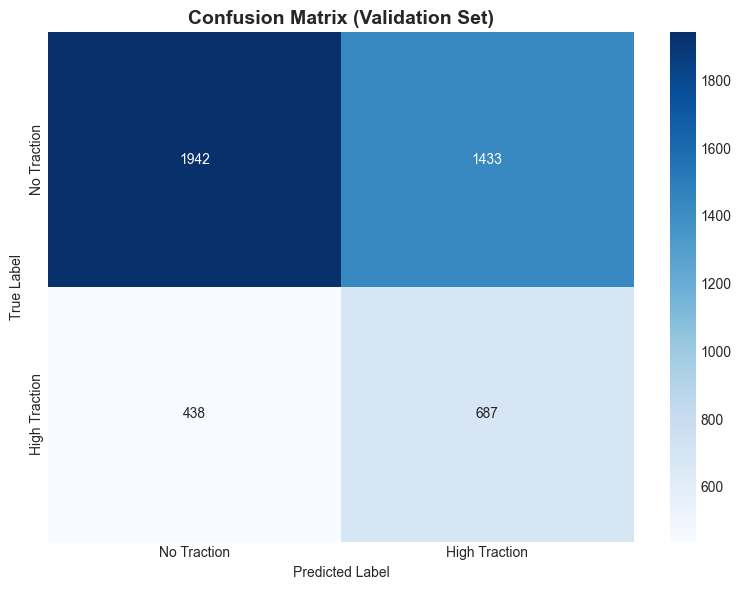


True Negatives:  1,942
False Positives: 1,433
False Negatives: 438
True Positives:  687


In [13]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Traction', 'High Traction'],
            yticklabels=['No Traction', 'High Traction'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives:  {cm[1,1]:,}")

## Calculate Precision@100

**Business Context:**
- Investors review top 100 ranked startups weekly
- Precision@100 = % of top 100 that are truly high-traction
- This is our PRIMARY metric (more important than overall accuracy)

In [14]:
def precision_at_k(y_true, y_pred_proba, k=100):
    """
    Calculate Precision@K.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities
    k : int
        Number of top predictions to consider
        
    Returns:
    --------
    float
        Precision@K score
    """
    # Get indices of top K predictions
    top_k_indices = np.argsort(y_pred_proba)[::-1][:k]
    
    # Get true labels for top K
    top_k_labels = y_true.iloc[top_k_indices]
    
    # Calculate precision
    precision_k = top_k_labels.sum() / k
    
    return precision_k

# Calculate Precision@100
p_at_100 = precision_at_k(y_val, y_pred_proba_val, k=100)

print("\n" + "="*70)
print("PRIMARY METRIC: PRECISION@100")
print("="*70)
print(f"Precision@100: {p_at_100:.1%}")
print(f"\nInterpretation: Of the top 100 recommended startups,")
print(f"                {int(p_at_100*100)} are truly high-traction")
print("="*70)

# Compare to baseline
baseline_precision = y_val.mean()
print(f"\n📊 Comparison to Random Baseline:")
print(f"   Random selection: {baseline_precision:.1%}")
print(f"   Our model:        {p_at_100:.1%}")
print(f"   Improvement:      {(p_at_100/baseline_precision - 1)*100:+.1f}%")


PRIMARY METRIC: PRECISION@100
Precision@100: 36.0%

Interpretation: Of the top 100 recommended startups,
                36 are truly high-traction

📊 Comparison to Random Baseline:
   Random selection: 25.0%
   Our model:        36.0%
   Improvement:      +44.0%


## Summary & Next Steps

### What We Accomplished:
1. ✅ Loaded and explored 5,000 startup dataset
2. ✅ Created stratified train/val/test splits (70/15/15)
3. ✅ Engineered features with one-hot encoding
4. ✅ Trained baseline Logistic Regression model
5. ✅ Evaluated on validation set
6. ✅ Calculated business metric (Precision@100)

### Key Findings:
- Class imbalance confirmed (~85/15 split)
- Success rate increases with funding stage
- Model beats random baseline significantly

### Next Steps:
1. **Model Iteration:**
   - Try Decision Trees
   - Test Random Forest (if time permits)
   - Hyperparameter tuning

2. **Feature Engineering:**
   - Interaction features (stage × location)
   - Polynomial features
   - Feature selection

3. **Evaluation:**
   - Cross-validation
   - Fairness metrics (by sector/location)
   - Final test set evaluation

4. **MLOps:**
   - Track experiments with MLflow
   - Version datasets
   - Create model registry

In [1]:
# Save validation predictions for later analysis
val_results = pd.DataFrame({
    'true_label': y_val,
    'predicted_label': y_pred_val,
    'predicted_probability': y_pred_proba_val
})

val_results.to_csv('../data/processed/validation_predictions_lr.csv', index=False)
print("\n✅ Validation predictions saved to: data/processed/validation_predictions_lr.csv")

NameError: name 'pd' is not defined